## Check sensitivities to parameters

In [1]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
mpl.rcParams['font.family'] = 'sans-serif'
# 優先順位を Helvetica → Arial の順に設定（必要なら他のフォントを追加）
mpl.rcParams['font.sans-serif'] = ['Helvetica', 'Arial']    
from param_test import set_param

In [2]:
param_fix_dict = {
    "temp_sea_init_list": [5, 10, 15]    ,
    "BOOL_REEVAP": False, # 十分湿っている雲には返らない
    "temp_surf": [0],
}

## Calc d-excess

In [17]:
def calc_dex(dD, d18O):
    return dD - 8 * d18O

ind=0

def read_csvfile(ind=0, title="tuning_parallel", ISO_TYPE="HDO", model="IsoGSM"):
    if model == "MIROC5-iso":
        title_updated = f"{title}_MIROC"
    else:
        title_updated = title
    df_HDO = pd.read_csv(f"tables/{title_updated}_HDO_{ind}.csv")
    df_H218O = pd.read_csv(f"tables/{title_updated}_H218O_{ind}.csv")

    df_dex = df_HDO.copy()
    for param in ["snow_delta", "ry_fin_delta", "obs_fin_delta"]:
        df_dex[param] = calc_dex(df_HDO[param], df_H218O[param])
    if ISO_TYPE == "HDO":
        return df_HDO
    elif ISO_TYPE == "H218O":
        return df_H218O
    elif ISO_TYPE == "dex":
        return df_dex
    else:
        raise ValueError(f"ISO_TYPE is invalid: {ISO_TYPE}")

(array([  12.,   30.,   64.,  154.,  260.,  460., 1374.,  506.,  180.,
          22.]),
 array([-26.51880783, -24.79728856, -23.07576929, -21.35425002,
        -19.63273075, -17.91121147, -16.1896922 , -14.46817293,
        -12.74665366, -11.02513439,  -9.30361511]),
 <BarContainer object of 10 artists>)

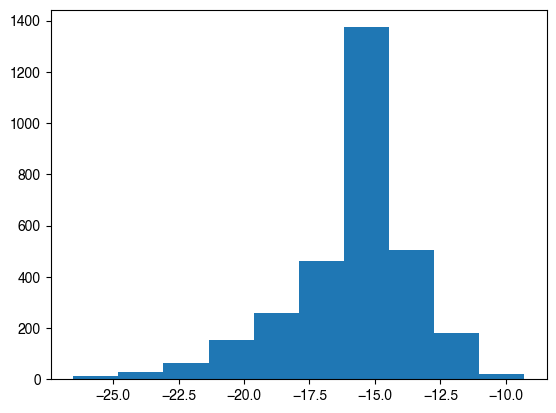

In [27]:
df = pd.read_csv(f"tables/tuning_parallel_MIROC_H218O_0.csv")

plt.hist(df["obs_fin_delta"])

## plot all parameters

In [18]:
ylabel_dict = {
    "HDO": "$\mathsf{\delta D}$",
    "H218O": "$\mathsf{\delta ^{18}O}$",
    "dex": "d-excess"
}

ylim_dict = {
    # "HDO": (-176,-88),
    # "H218O": (-22,-11),
    # "dex": (-20,10)
    "HDO": (-400,0),
    "H218O": (-50,0),
    "dex": (-100,100)
    
}

In [19]:
def compute_mean(
    df: pd.DataFrame, 
    y_var: str, 
    param: str, 
    param_val
) -> float:
    filtered_vals = df.loc[df[param] == param_val, y_var].replace(-np.inf, np.nan)
    if len(filtered_vals) == 0:
        
        print(f"param={param}, param_val={param_val}, df[param]={df[param]}")
    return np.nanmean(filtered_vals)

def plot_violinplot(
    df: pd.DataFrame, 
    y_var: str, 
    param_name: str, 
    means, 
    ISO_TYPE: str, 
    title: str
) -> None:
                           
    plt.figure(figsize=(6,6))
    plt.title(title)
    ax = sns.violinplot(data=df, y=y_var, hue=param_name)
                           
    if means is not None:
        mean_labels = [f"{val:.2f}" for val in means]
        handles, labels = ax.get_legend_handles_labels()
        new_labels = [f"{l} (mean={m})" for l, m in zip(labels, mean_labels)]
        ax.legend(handles, new_labels, title=param_name)
    else:
        ax.legend()
        
    ax.set_ylabel(f"Final water vapor {ylabel_dict[ISO_TYPE]} [‰]")
    ax.set_ylim(ylim_dict[ISO_TYPE])
    plt.show()

def check_sensitivity(
    y_var: str ="obs_fin_delta", 
    ISO_TYPE: str = "HDO", 
    ind: int = 0, 
    SHOW_FIG: bool =True, 
    ALL_PARAM: bool =True, 
    param_fix_dict: dict = None,
    model: str = "IsoGSM"
) -> None:
    if param_fix_dict is None:
        raise ValueError(f"param_fix_dict must be provided")
        
    sst_ini = param_fix_dict["temp_sea_init_list"][ind]
    param_test_dict = get_param_test_dict(ISO_TYPE, ALL_PARAM, model)
    
    df = read_csvfile(ind=ind, ISO_TYPE=ISO_TYPE, model=model)

    if ALL_PARAM:
        sens_param_list = list(param_test_dict.keys())
        df_filtered = df.copy()
    else:    
        sens_param_list, df_filtered = get_sens_param(param_test_dict, df.copy(), ind)

    mean_dict = {}
    for param in sens_param_list:
        param_name = param[:-5] if param.endswith("_list") else param
        mean_dict[param_name] = {}

        means = []
        try:
            for param_val in param_test_dict[param]:
                param_val_adjusted = param_val[ind] if isinstance(param_val, list) and param_val else param_val

                mean_val = compute_mean(df_filtered, y_var, param_name, param_val_adjusted)
                means.append(mean_val)
                mean_dict[param_name][param_val_adjusted] = mean_val

            if SHOW_FIG:
                title = f"{param_name}\n(temp_sea_init = {sst_ini})"
                plot_violinplot(df_filtered, y_var, param_name, means, ISO_TYPE, title)

        except (ValueError, KeyError, TypeError) as e:
            print(f"Error in {param_name}: {e}")

    return mean_dict

def get_sens_param(param_test_dict: dict, df: pd.DataFrame, ind: int) -> (list, pd.DataFrame):
    # print("Fixed parameters:")
    sens_param_list = []
    for param, val_list in param_test_dict.items():
        if len(val_list) > 1:
            sens_param_list.append(param)
        else:
            fixed_val = val_list[0]
            param_name = param[:-5] if param.endswith("_list") else param
            if param.endswith("_list"):
                fixed_val = fixed_val[ind]
            # print(f"- {param_name}={fixed_val}")
            
            df = df[df[param_name] != fixed_val]
            # print(f"- Excluding {param_name}={fixed_val}")
    return sens_param_list, df

def get_param_test_dict(
    ISO_TYPE: str, 
    ALL_PARAM: bool = True,
    model: str = "IsoGSM"
) -> dict:
    return set_param("HDO", ALL_PARAM, model) if ISO_TYPE == "dex" else set_param(ISO_TYPE, ALL_PARAM, model)
    
def compute_mean_anom_ranking(
    mean_dict: dict, ISO_TYPE: str, ind: int, param_fix_dict: dict = None, ALL_PARAM: bool = True) -> pd.DataFrame:

    if param_fix_dict is None:
        raise ValueError("param_fix_dict must be provided")
    sst_ini = param_fix_dict["temp_sea_init_list"][ind]
    # param_test_dict = get_param_test_dict(ISO_TYPE, ALL_PARAM)

    mean_sort_dict={}
    for param, values in mean_dict.items():
        try:
            val_list = list(values.values())
            mean_sort_dict[param] = np.abs(val_list[0]-val_list[-1]) if len(val_list) >= 2 else np.nan

        except KeyError as e:
            print(f"KeyError: {param}: {e}")

    index = f"anom_abs_{ISO_TYPE}_{sst_ini}"
    df_mean_sort = pd.DataFrame(mean_sort_dict, index=[index]).T
        
    return df_mean_sort.sort_values(index, ascending=False)

### dD

In [20]:
for ind in range(len(param_fix_dict["temp_sea_init_list"])):
    mean_dict_HDO = check_sensitivity(param_fix_dict=param_fix_dict, y_var="obs_fin_delta", ISO_TYPE="HDO", SHOW_FIG=False, ind=ind, model="MIROC5-iso")
    display(compute_mean_anom_ranking(mean_dict_HDO, "HDO", ind, param_fix_dict=param_fix_dict))
    mean_dict_H218O = check_sensitivity(param_fix_dict=param_fix_dict, y_var="obs_fin_delta", ISO_TYPE="H218O", SHOW_FIG=False, ind=ind, model="MIROC5-iso")
    display(compute_mean_anom_ranking(mean_dict_H218O, "H218O", ind, param_fix_dict=param_fix_dict))
    
    mean_dict_dex = check_sensitivity(param_fix_dict=param_fix_dict, y_var="obs_fin_delta", ISO_TYPE="dex", SHOW_FIG=False, ind=ind, model="MIROC5-iso")
    display(compute_mean_anom_ranking(mean_dict_dex, "dex", ind, param_fix_dict=param_fix_dict))

,anom_abs_HDO_5
temp_air_fin,40.085678
prcp_duration,19.378598
prcp_perday,12.696549
temp_air_init,12.145567
resub_factor,10.802241
dt,3.135390
p_top,3.011889
ALPHA_RY_MODE,1.283713
h_air,0.963631
surface_wind,0.466499


,anom_abs_H218O_5
temp_air_fin,3.356479
h_air,1.064376
prcp_duration,1.046322
prcp_perday,0.685998
temp_air_init,0.596544
resub_factor,0.583833
surface_wind,0.520148
dt,0.264729
p_top,0.163978
ALPHA_RY_MODE,0.016125


,anom_abs_dex_5
temp_air_fin,14.313249
temp_air_init,12.183864
prcp_duration,10.756063
prcp_perday,7.613700
resub_factor,6.304557
dt,2.074208
p_top,1.901001
h_air,1.630329
ALPHA_RY_MODE,1.109196
surface_wind,0.415210


,anom_abs_HDO_10
temp_air_fin,40.044279
prcp_duration,32.428913
prcp_perday,21.289523
resub_factor,18.142096
temp_air_init,10.890297
p_top,5.192937
dt,3.188334
ALPHA_RY_MODE,1.608189
h_air,0.980651
surface_wind,0.471677


,anom_abs_H218O_10
temp_air_fin,3.343886
prcp_duration,2.299153
prcp_perday,1.509459
resub_factor,1.286272
h_air,1.068768
temp_air_init,0.537064
surface_wind,0.514378
p_top,0.368198
dt,0.276779
ALPHA_RY_MODE,0.062305


,anom_abs_dex_10
prcp_duration,14.028119
temp_air_fin,13.806927
temp_air_init,10.803477
prcp_perday,9.792586
resub_factor,7.874327
p_top,2.504179
dt,2.028914
ALPHA_RY_MODE,1.431602
h_air,0.400855
surface_wind,0.341302


,anom_abs_HDO_15
prcp_duration,44.286380
temp_air_fin,40.264134
prcp_perday,29.072699
resub_factor,24.775145
temp_air_init,10.136069
p_top,7.091206
dt,3.364142
ALPHA_RY_MODE,1.751002
h_air,0.992087
surface_wind,0.469790


,anom_abs_H218O_15
prcp_duration,3.475224e+00
temp_air_fin,3.346537e+00
prcp_perday,2.281425e+00
resub_factor,1.944164e+00
h_air,1.075278e+00
p_top,5.564759e-01
surface_wind,5.094999e-01
temp_air_init,4.991774e-01
dt,2.936340e-01
ALPHA_RY_MODE,7.535213e-02


,anom_abs_dex_15
prcp_duration,16.654963
temp_air_fin,14.193920
prcp_perday,11.862838
temp_air_init,9.888757
resub_factor,9.138200
p_top,3.318070
dt,2.355759
ALPHA_RY_MODE,1.899131
h_air,0.869535
surface_wind,0.480711


In [14]:
for ind in range(len(param_fix_dict["temp_sea_init_list"])):
    mean_dict_HDO = check_sensitivity(param_fix_dict=param_fix_dict, y_var="obs_fin_delta", ISO_TYPE="HDO", SHOW_FIG=False, ind=ind, model="MIROC5-iso")
    display(compute_mean_anom_ranking(mean_dict_HDO, "HDO", ind, param_fix_dict=param_fix_dict))
    mean_dict_H218O = check_sensitivity(param_fix_dict=param_fix_dict, y_var="obs_fin_delta", ISO_TYPE="H218O", SHOW_FIG=False, ind=ind, model="MIROC5-iso")
    display(compute_mean_anom_ranking(mean_dict_H218O, "H218O", ind, param_fix_dict=param_fix_dict))
    
    mean_dict_dex = check_sensitivity(param_fix_dict=param_fix_dict, y_var="obs_fin_delta", ISO_TYPE="dex", SHOW_FIG=False, ind=ind, model="MIROC5-iso")
    display(compute_mean_anom_ranking(mean_dict_dex, "dex", ind, param_fix_dict=param_fix_dict))

,anom_abs_HDO_5
temp_air_fin,40.085678
prcp_duration,19.378598
prcp_perday,12.696549
temp_air_init,12.145567
resub_factor,10.802241
dt,3.135390
p_top,3.011889
ALPHA_RY_MODE,1.283713
h_air,0.963631
surface_wind,0.466499


,anom_abs_H218O_5
temp_air_fin,3.356479
h_air,1.064376
prcp_duration,1.046322
prcp_perday,0.685998
temp_air_init,0.596544
resub_factor,0.583833
surface_wind,0.520148
dt,0.264729
p_top,0.163978
ALPHA_RY_MODE,0.016125


,anom_abs_dex_5
temp_air_fin,14.313249
temp_air_init,12.183864
prcp_duration,10.756063
prcp_perday,7.613700
resub_factor,6.304557
dt,2.074208
p_top,1.901001
h_air,1.630329
ALPHA_RY_MODE,1.109196
surface_wind,0.415210


,anom_abs_HDO_10
temp_air_fin,40.044279
prcp_duration,32.428913
prcp_perday,21.289523
resub_factor,18.142096
temp_air_init,10.890297
p_top,5.192937
dt,3.188334
ALPHA_RY_MODE,1.608189
h_air,0.980651
surface_wind,0.471677


,anom_abs_H218O_10
temp_air_fin,3.343886
prcp_duration,2.299153
prcp_perday,1.509459
resub_factor,1.286272
h_air,1.068768
temp_air_init,0.537064
surface_wind,0.514378
p_top,0.368198
dt,0.276779
ALPHA_RY_MODE,0.062305


,anom_abs_dex_10
prcp_duration,14.028119
temp_air_fin,13.806927
temp_air_init,10.803477
prcp_perday,9.792586
resub_factor,7.874327
p_top,2.504179
dt,2.028914
ALPHA_RY_MODE,1.431602
h_air,0.400855
surface_wind,0.341302


,anom_abs_HDO_15
prcp_duration,44.286380
temp_air_fin,40.264134
prcp_perday,29.072699
resub_factor,24.775145
temp_air_init,10.136069
p_top,7.091206
dt,3.364142
ALPHA_RY_MODE,1.751002
h_air,0.992087
surface_wind,0.469790


,anom_abs_H218O_15
prcp_duration,3.475224e+00
temp_air_fin,3.346537e+00
prcp_perday,2.281425e+00
resub_factor,1.944164e+00
h_air,1.075278e+00
p_top,5.564759e-01
surface_wind,5.094999e-01
temp_air_init,4.991774e-01
dt,2.936340e-01
ALPHA_RY_MODE,7.535213e-02


,anom_abs_dex_15
prcp_duration,16.654963
temp_air_fin,14.193920
prcp_perday,11.862838
temp_air_init,9.888757
resub_factor,9.138200
p_top,3.318070
dt,2.355759
ALPHA_RY_MODE,1.899131
h_air,0.869535
surface_wind,0.480711


## plot sensitive parameters

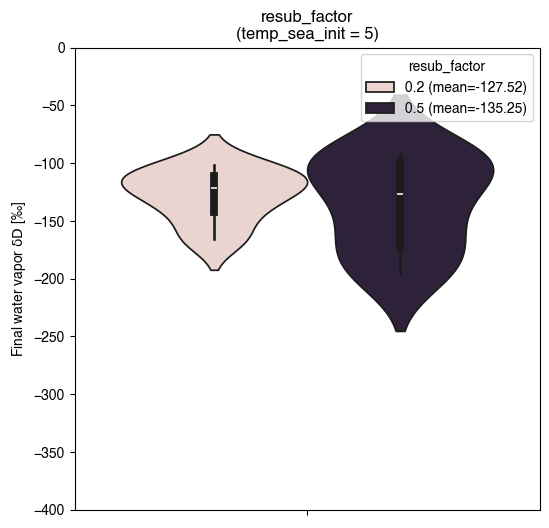

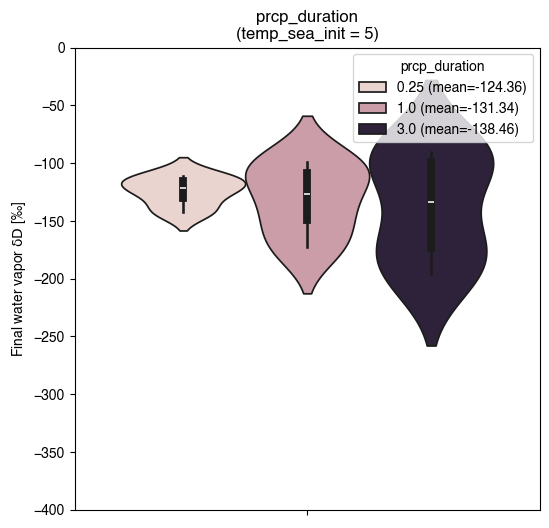

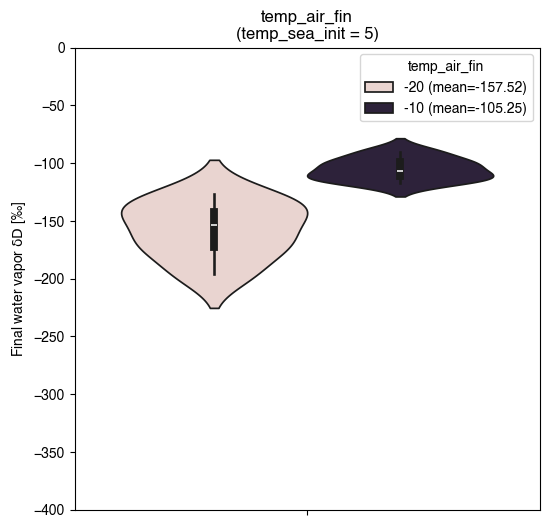

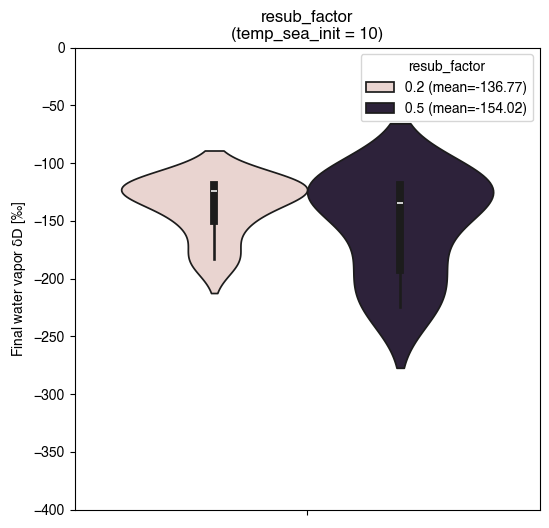

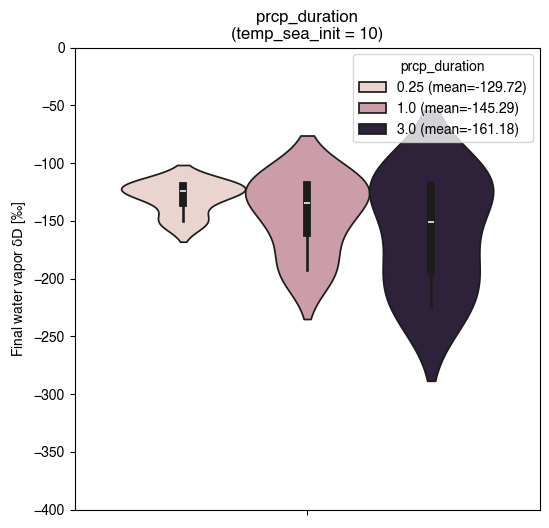

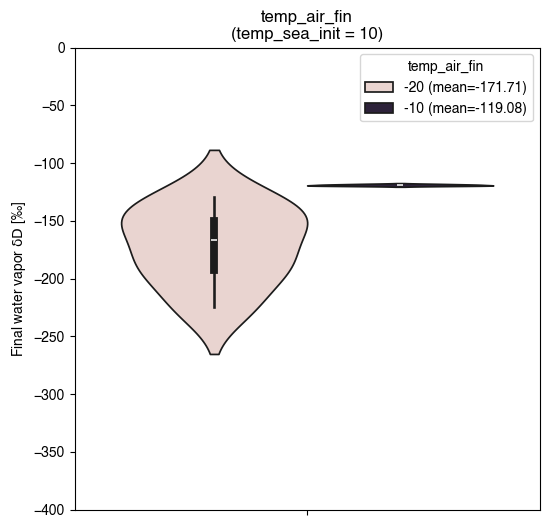

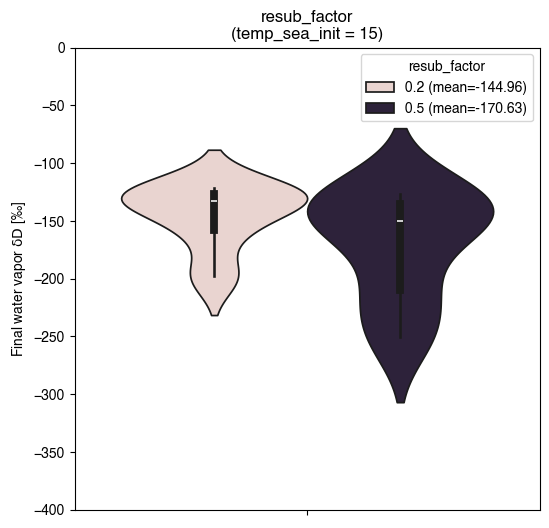

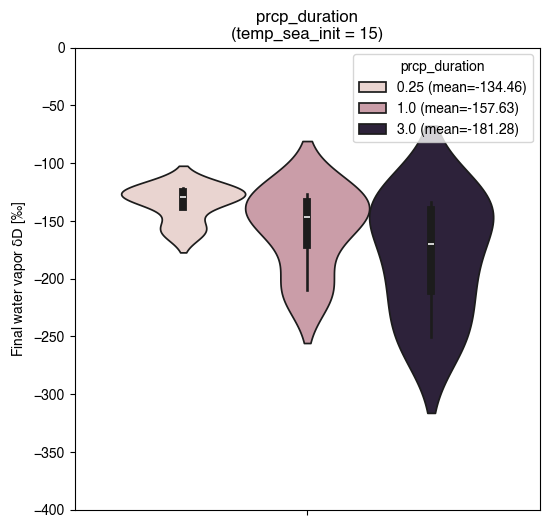

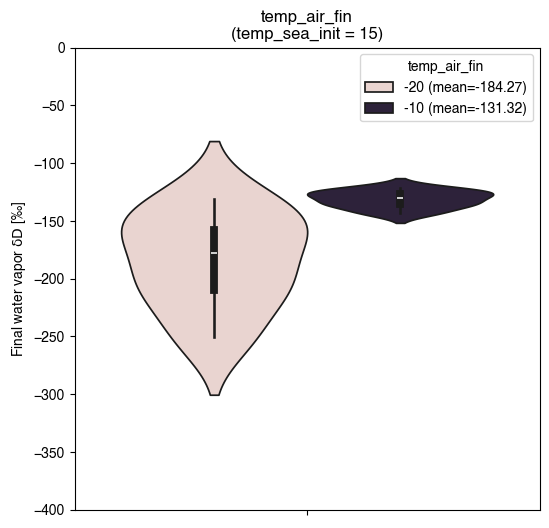

In [15]:
for ind in range(len(param_fix_dict["temp_sea_init_list"])):
    mean_dict_dD_sel = check_sensitivity(y_var="obs_fin_delta", param_fix_dict=param_fix_dict,
                                  ISO_TYPE="HDO", ind=ind, ALL_PARAM=False, model="MIROC5-iso")
    compute_mean_anom_ranking(mean_dict_dD_sel, "HDO", ind=ind, ALL_PARAM=False, param_fix_dict=param_fix_dict)

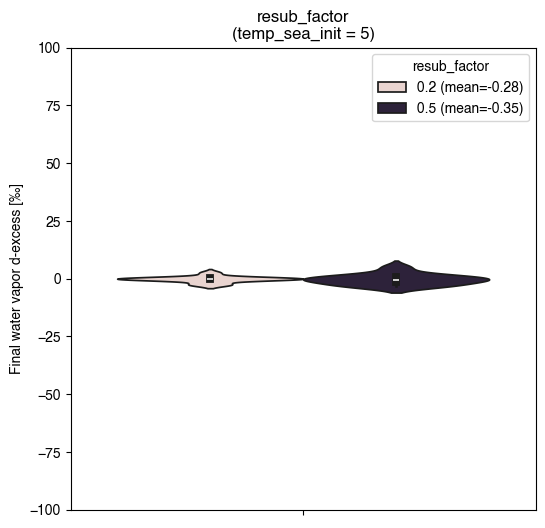

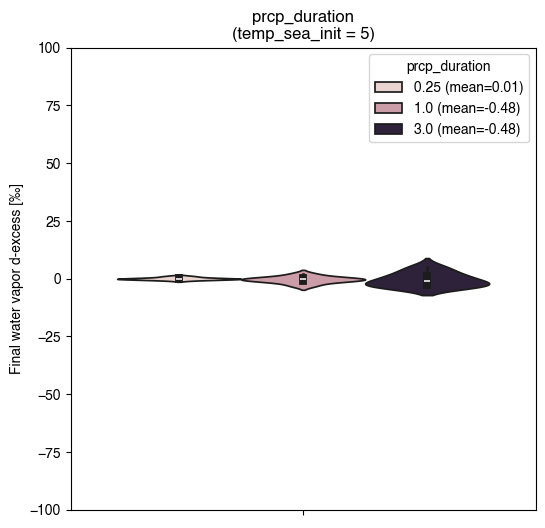

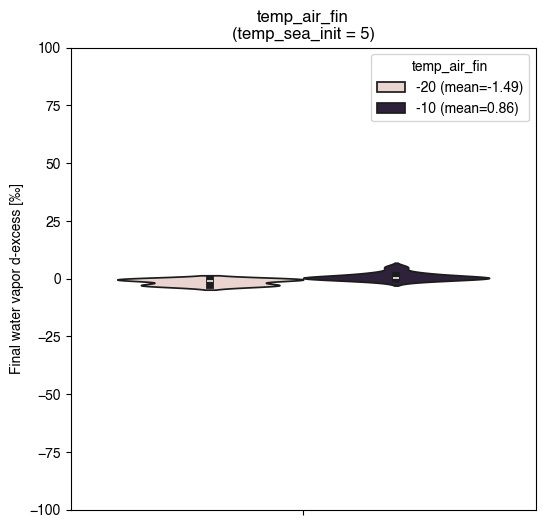

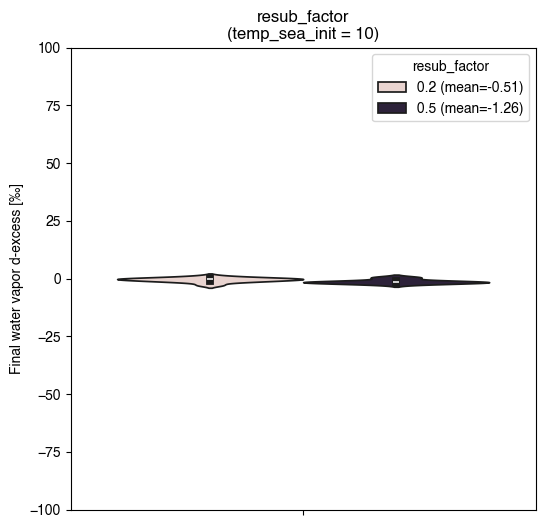

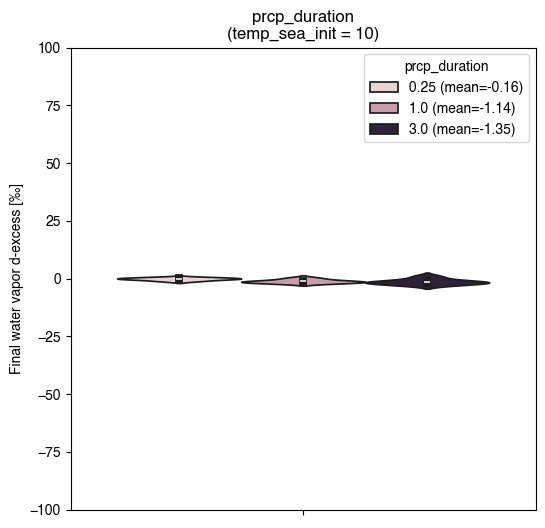

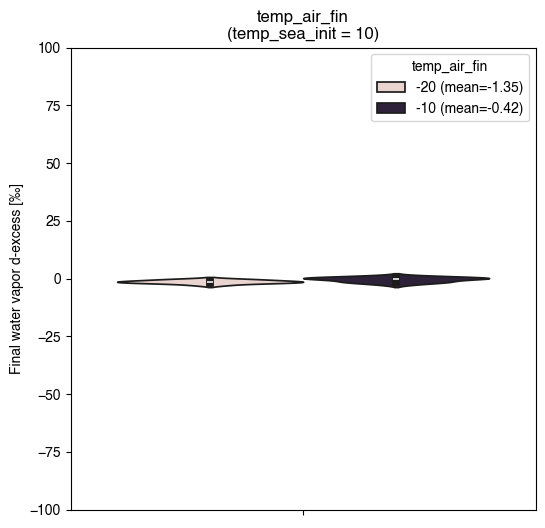

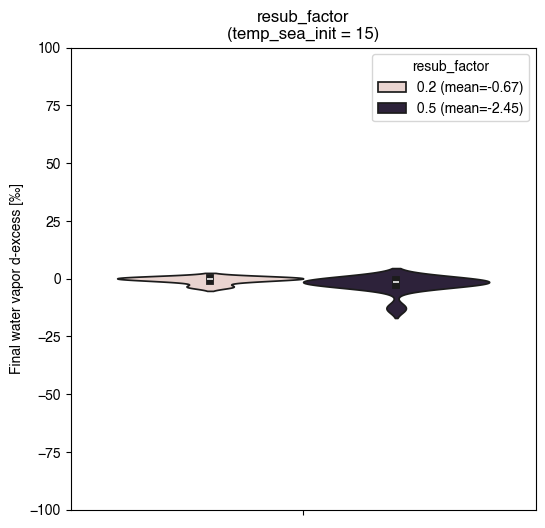

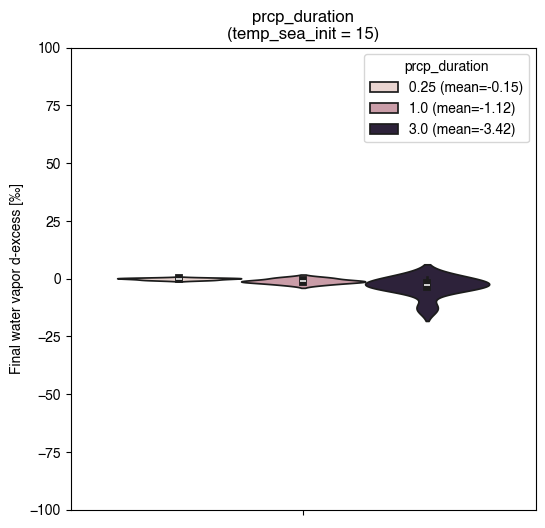

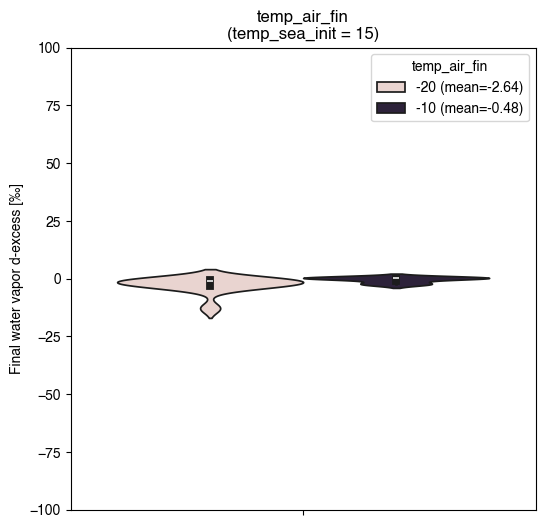

In [16]:
for ind in range(len(param_fix_dict["temp_sea_init_list"])):
    mean_dict_dex_sel = check_sensitivity(y_var="obs_fin_delta", param_fix_dict=param_fix_dict, 
                                      ISO_TYPE="dex", ind=ind, ALL_PARAM=False)
    compute_mean_anom_ranking(mean_dict_dex_sel, "dex", ind=ind, param_fix_dict=param_fix_dict)